  # Fourier Coefficients Evaluation using Python

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [2]:
# function
def f(x):
    # if (0<=x<np.pi):
    #     return 1
    # else:
    #     return -1
    val = np.where(0<=x<np.pi, 1, -1)
    return val
    
# half period
L = np.pi
# no of fourier terms
N = 50

In [3]:
# fourier coeff
def a0():
    val, _ = quad(lambda x: f(x), -L, L)
    return val/L

def an(n):
    val, _ = quad(lambda x: f(x)*np.cos(n*np.pi*x/L), -L, L)
    return val/L

def bn(n):
    val, _ = quad(lambda x: f(x)*np.sin(n*np.pi*x/L), -L, L)
    return val/L

In [4]:
# value of coeff
a0_val = a0()
a_val = [an(n) for n in range(1, N + 1)]
b_val = [bn(n) for n in range(1, N + 1)]

print(a0_val, a_val, b_val)

0.0 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] [1.2732395447351625, 1.0899529502209053e-16, 0.42441318157838764, 1.0051089433872239e-16, 0.2546479089470324, 3.5177479872902253e-16, 0.18189136353359414, -5.43818605928925e-16, 0.14147106052612907, -1.6648293491582657e-17, 0.11574904952137845, 2.7683501325461324e-16, 0.09794150344116648, 2.4299559926405767e-16, 0.08488263631567741, -2.0043906416344592e-16, 0.07489644380794998, 1.2878475573665222e-15, 0.06701260761764039, -7.673606049974989e-16, 0.06063045451119861, 1.3765175482022996e-15, 0.05535824107544269, -8.783295297820349e-17, 0.05092958178940592, -3.318181101501594e-15, 0.04715702017537593, -7.595121593451756e-16, 0.04390481188741899, 3.500901740863332e-15, 0.04107224337855403, -2.247392144693868e-15, 0.03858301650712719, 2.233

In [5]:
# Reconstract functions
x_vals = np.linspace(0, 2*L, 1000)
f_fourier = np.full_like(x_vals, a0_val/2)

for n in range(1, N+1):
    f_fourier += a_val[n-1]*np.cos(n*np.pi*x_vals/L) + b_val[n-1]*np.sin(n*np.pi*x_vals/L)

f_original = np.array([f(x) for x in x_vals])

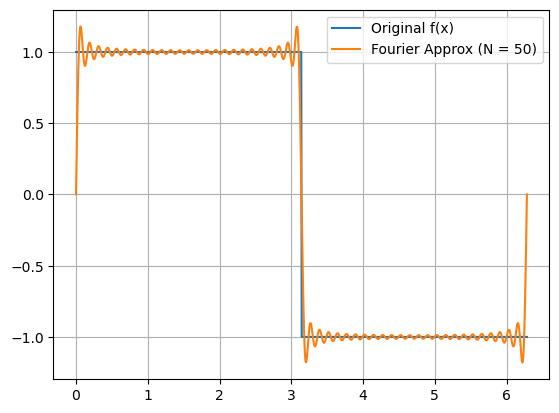

In [6]:
plt.plot(x_vals, f_original, label="Original f(x)")
plt.plot(x_vals, f_fourier, label = f"Fourier Approx (N = {N})")
plt.legend()
plt.grid(True)
plt.show()